<center> <h1> 02. Basis of Portfolio Choice <h1> <center>

From pag 28-29 of the course note. We compute the $\mu$ and $\sigma$ fot three portfolios. Suppose we only have a risk-free asset and a riskless one. We have three portfolios with weights of the $R_i$ stored in the `w` dictionary. 

In [1]:

# Weights for the risky asset
w = {'A' : 0.5, 'B': 1, 'C': 2}

# Data
risky_mu = 0.095
risky_sigma = 0.08
risk_free = 0.03

# Compute the mean
mu_A = w['A']*risky_mu + (1-w['A'])*risk_free
mu_B = w['B']*risky_mu + (1-w['B'])*risk_free
mu_C = w['C']*risky_mu + (1-w['C'])*risk_free

print(f"The expected return of Portfolio A is {mu_A*100}")
print(f"The expected return of Portfolio B is {mu_B*100}")
print(f"The expected return of Portfolio C is {mu_C*100}")

# Compute the theoretical sd
std_A = abs(w['A'])*risky_sigma
std_B = abs(w['B'])*risky_sigma
std_C = abs(w['C'])*risky_sigma

print(f"The std of Portfolio A is {std_A*100}")
print(f"The std of Portfolio B is {std_B*100}")
print(f"The std of Portfolio C is {std_C*100}")



The expected return of Portfolio A is 6.25
The expected return of Portfolio B is 9.5
The expected return of Portfolio C is 16.0
The std of Portfolio A is 4.0
The std of Portfolio B is 8.0
The std of Portfolio C is 16.0


Now let's see the effect of a different portfolio w on the mean and std. Recall that we only have two assets:

$$ R_p = R_f \cdot (1-w) + R \cdot w $$

Hence:

$$ \mathbb{E}[R_p] = R_f \cdot (1-w) + \mu \cdot w$$

And the variance:

$$ \mathbb{V}[R_p] =  \sigma^2 \cdot w^2 $$

Where R is a random variable: $R \sim (\mu, \sigma^2)$. The shape ratio is constant here

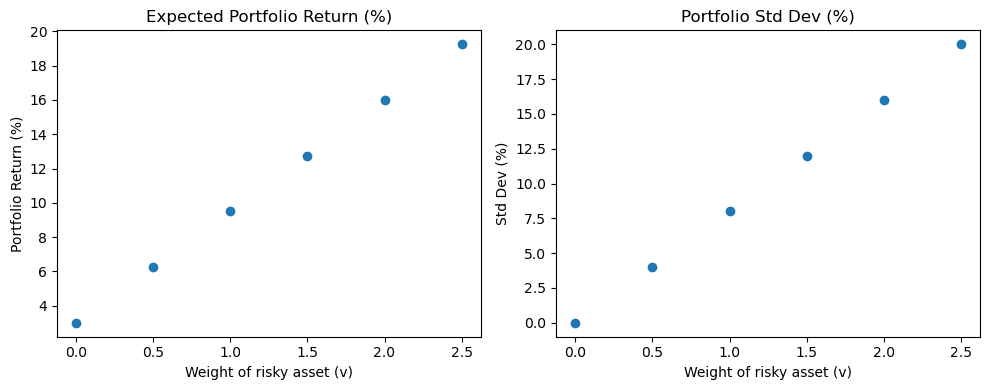

In [2]:
import matplotlib.pyplot as plt 
import numpy as np
import warnings

# Suppress all warnings
warnings.filterwarnings("ignore")

v = np.array([0, 0.5, 1.0, 1.5, 2.0, 2.5])
R_f = 0.03
sigma = 0.08
mu = 0.095

# Portfolio return for different v
R_p = v * mu + (1 - v) * R_f
Std_Rp = v * sigma  # standard deviation scales with v (assuming no abs)


# Sharpe ratio is constant
sp = (R_p - R_f) / Std_Rp

# Plot
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(v, R_p * 100)
plt.title("Expected Portfolio Return (%)")
plt.ylabel("Portfolio Return (%)")
plt.xlabel("Weight of risky asset (v)")

plt.subplot(1,2,2)
plt.scatter(v, Std_Rp * 100)
plt.title("Portfolio Std Dev (%)")
plt.ylabel("Std Dev (%)")
plt.xlabel("Weight of risky asset (v)")

plt.tight_layout()
plt.show()

Pick a portfolio model with two assets. Then we plot the std given the correlation of the two assets.

The portfolio std is 0.11370136322841516


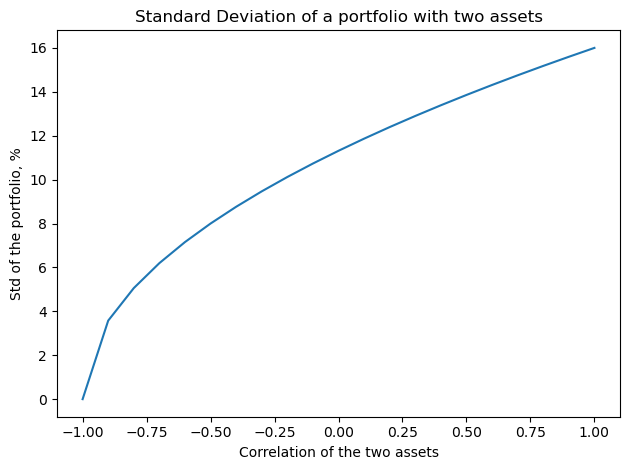

In [3]:
# Select a correlation
p = 0.01

# Select a fix std for the two assets
omega_1 = 0.16
omega_2 = 0.16

# Compute the covariance
cov = p*omega_1*omega_2

# Fix the Weights
w_1 = 0.5
w_2 = 1-w_1

# Portfolio variance and std
var = w_1**2*omega_1**2 + w_2**2*omega_2**2 + 2*w_1*w_2*cov
std = np.sqrt(var)

print(f"The portfolio std is {std}")

### For different p values
p = np.arange(-1,1.1,0.1)

# Covariance
cov = p*omega_1*omega_2

# Variance
var = w_1**2*omega_1**2 + w_2**2*omega_2**2 + 2*w_1*w_2*cov

# Std
std = np.sqrt(var)*100


plt.plot(p,std)
plt.title("Standard Deviation of a portfolio with two assets")
plt.xlabel("Correlation of the two assets")
plt.ylabel("Std of the portfolio, %")
plt.tight_layout()
plt.show()


The porfolio with std zero is a **perfect hedged** porfolio, since the std is zero, and you have a fix payoff. 

## Diversification gains

For a portfolio $p$ that is Equally Weighted (EQ) the variance can be expressed as:

$$ \mathbb{V}[R_p] = \mathbb{V}[\bold{w}'R] = \frac{\bold{1}'}{n}\mathbb{V}[R] \frac{\bold{1}}{n} =  \frac{1}{n}(\bar{\sigma^2} - \bar{\sigma}_{ij}) + \bar{\sigma}_{ij}  $$

For $\bar{\sigma}_{ij}, \bar{\sigma}^2$ the average covariance and variance across the $n$ assets that compose the portfolio

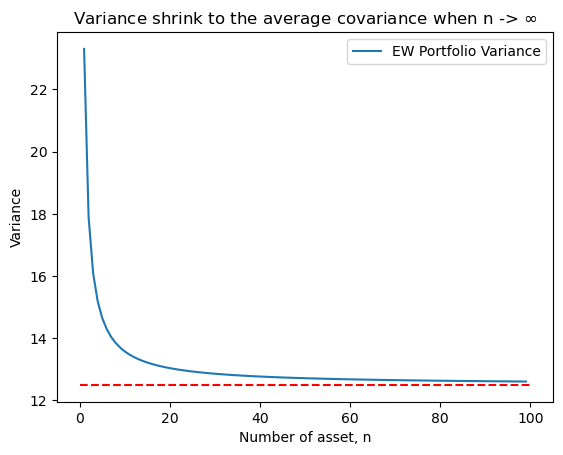

In [17]:
# Select a max number of assets
n = 100

# Select the average covariance and variance
sigma_ij = 12.5
sigma = 23.3

def ewPortfolioVariance(n,sigma,cov):
    """Equally Weighted Portfolio Variance"""
    return 1/n*(sigma-cov)+cov

var_plot = []

for n_i in range(1,n):
    var_p = ewPortfolioVariance(n = n_i,sigma = sigma, cov = sigma_ij)
    var_plot.append(var_p)

plt.plot(np.arange(1,n), var_plot, label = "EW Portfolio Variance")
plt.hlines(y = sigma_ij, xmin=0, xmax=n, linestyles="--", color = "red")
plt.title("Variance shrink to the average covariance when n -> $\infty$")
plt.xlabel("Number of asset, n")
plt.ylabel("Variance")
plt.legend()
plt.show()